## Tree-Based Models

Tree-based .....

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [ ]:
df = pd.read_csv("Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA.csv")
df.head()

,rate_avg,photos_count,superhost,latitude,longitude,guests,bedrooms,beds,baths,min_nights,...,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days,avg_temp
0,36.3,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,-3.925
1,35.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,0.770
2,35.9,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,7.040
3,36.0,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,13.890
4,36.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,19.470


In [ ]:
X = df.drop(columns=["rate_avg"])
y = df["rate_avg"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(2580, 70) (645, 70) (2580,) (645,)


### Decision Tree (Baseline)

We first trained a decision tree regressor as a baseline tree-based model. This allows us to see how a single tree performs when predicting Airbnb listing price.

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MSE:", dt_mse)
print("RMSE:", dt_rmse)
print("R^2:", dt_r2)

Decision Tree Results
MSE: 622.3603565891473
RMSE: 24.94715127202197
R^2: 0.9415133226119903


### Hyperparameter Tuning - Decision Tree

In [ ]:
dt_mse = {'k': [], 'train_mse': [], 'test_mse': []}

for k in range(1, 31):
    print("Fit with max_depth:", k, end='\r', flush=True)

    model = DecisionTreeRegressor(max_depth=k, random_state=42)
    model.fit(X_train, y_train)

    preds_train = model.predict(X_train)
    preds_test = model.predict(X_test)

    dt_mse['k'].append(k)
    dt_mse['train_mse'].append(mean_squared_error(y_train, preds_train))
    dt_mse['test_mse'].append(mean_squared_error(y_test, preds_test))

# Find the depth with the minimum test MSE
best_idx = dt_mse['test_mse'].index(min(dt_mse['test_mse']))
best_depth = dt_mse['k'][best_idx]

print("\nDepth of the model yielding minimum test MSE is:", best_depth)
print("Minimum test MSE:", min(dt_mse['test_mse']))

Fit with max_depth: 30
Depth of the model yielding minimum test MSE is: 19
Minimum test MSE: 597.653549032326


Training vs Test MSE by Tree Depth

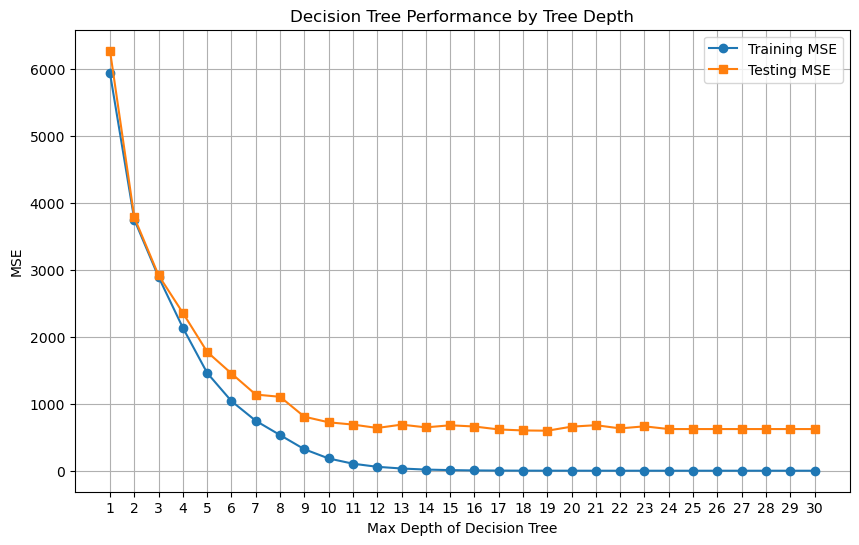

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(dt_mse['k'], dt_mse['train_mse'], label='Training MSE', marker='o')
plt.plot(dt_mse['k'], dt_mse['test_mse'], label='Testing MSE', marker='s')
plt.title('Decision Tree Performance by Tree Depth')
plt.xlabel('Max Depth of Decision Tree')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.xticks(dt_mse['k'])
plt.show()

In [ ]:
best_dt = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_dt.fit(X_train, y_train)

y_pred_dt_tuned = best_dt.predict(X_test)

dt_tuned_mse = mean_squared_error(y_test, y_pred_dt_tuned)
dt_tuned_rmse = np.sqrt(dt_tuned_mse)
dt_tuned_r2 = r2_score(y_test, y_pred_dt_tuned)

print("Tuned Decision Tree Results")
print("MSE:", dt_tuned_mse)
print("RMSE:", dt_tuned_rmse)
print("R^2:", dt_tuned_r2)

Tuned Decision Tree Results
MSE: 597.653549032326
RMSE: 24.44695377817707
R^2: 0.9438351592578571


### Random Forest Regressor (Baseline)

We then trained a random forest regressor, which combines many decision trees. This helps reduce variance and improves predictive performance compared to a single tree.

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R^2:", rf_r2)

Random Forest Results
MSE: 414.3244271705428
RMSE: 20.35496075089664
R^2: 0.9610636203779082


### Hyperparameter Tuning - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize base random forest model
rf_clf = RandomForestRegressor(random_state=42)

# Define parameter grid
rf_params = {
    'max_depth': np.arange(5, 31, 5),
    'n_estimators': np.arange(50, 251, 50)
}

# Grid search
rf_grid_search = GridSearchCV(
    estimator=rf_clf,
    param_grid=rf_params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='neg_mean_absolute_error',
    return_train_score=True
)

rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 5, 10..., 20, 25, 30]), 'n_estimators': array([ 50, 1...50, 200, 250])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [ ]:
print("Best Random Forest parameters:")
print(rf_grid_search.best_params_)

Best Random Forest parameters:
{'max_depth': np.int64(25), 'n_estimators': np.int64(250)}


In [ ]:
best_rf = rf_grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

rf_tuned_mse = mean_squared_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(rf_tuned_mse)
rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Results")
print("MSE:", rf_tuned_mse)
print("RMSE:", rf_tuned_rmse)
print("R^2:", rf_tuned_r2)

Tuned Random Forest Results
MSE: 418.15676360195647
RMSE: 20.44888172008329
R^2: 0.9607034743272587


### Cross-Validation

To obtain a more reliable estimate of model performance, we also used 5-fold cross-validation. This helps reduce the chance of relying too heavily on one train/test split.

In [ ]:
dt_cv = cross_val_score(
    DecisionTreeRegressor(random_state=42),
    X, y,
    cv=5,
    scoring="neg_mean_squared_error"
)

rf_cv = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42),
    X, y,
    cv=5,
    scoring="neg_mean_squared_error"
)

print("Decision Tree CV RMSE:", np.mean(np.sqrt(-dt_cv)))
print("Random Forest CV RMSE:", np.mean(np.sqrt(-rf_cv)))

Decision Tree CV RMSE: 70.69037091262075
Random Forest CV RMSE: 51.700107496239184


### Feature Importance

One advantage of random forests is that they provide feature importance scores. These help show which variables contribute most to predicting listing price.

In [ ]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

guests                    0.517338
bedrooms                  0.178485
min_nights                0.051733
cleaning_fee              0.044653
longitude                 0.021598
num_reviews               0.019295
latitude                  0.019204
room_type_private_room    0.016888
rating_overall            0.014389
photos_count              0.012609
dtype: float64


### Baseline Gradient Boosting Model

We first train a Gradient Boosting model using default-style parameters. This serves as a baseline before tuning.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_features=5,
    max_depth=5,
    random_state=42
)

model_gb.fit(X_train, y_train)

preds_gb = model_gb.predict(X_test)

mse = mean_squared_error(y_test, preds_gb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds_gb)

print("Gradient Boosting Results")
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Gradient Boosting Results
MSE: 960.648177409751
RMSE: 30.99432492263303
R²: 0.9097225274060404


### Hyperparameter Tuning

We perform hyperparameter tuning using GridSearchCV to improve model performance. This tests different combinations of parameters and selects the best model.

In [ ]:
gbr = GradientBoostingRegressor(random_state=156)
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': np.arange(5, 30, 5),
    'n_estimators': np.arange(50, 210, 50),
    'learning_rate': np.arange(0.01, 0.31, 0.1)
}

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='neg_mean_absolute_error',
    return_train_score=True
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...dom_state=156)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': array([0.01, 0.11, 0.21]), 'max_depth': array([ 5, 10, 15, 20, 25]), 'n_estimators': array([ 50, 100, 150, 200])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

### Best Parameters

Extract the best parameters found during grid search

In [ ]:
print("Best parameters found:", grid_search.best_params_)

Best parameters found: {'learning_rate': np.float64(0.21000000000000002), 'max_depth': np.int64(5), 'n_estimators': np.int64(200)}


### Evaluate Best Model

We evaluate the tuned model on the test set using MSE and R²

In [ ]:
clf_best = grid_search.best_estimator_

y_test_pred = clf_best.predict(X_test)

print('Hyperparameter tuning of gradient boosting yields MSE and R-squared:',
      mean_squared_error(y_test, y_test_pred),
      r2_score(y_test, y_test_pred))

Hyperparameter tuning of gradient boosting yields MSE and R-squared: 439.9025024606614 0.9586599058387976


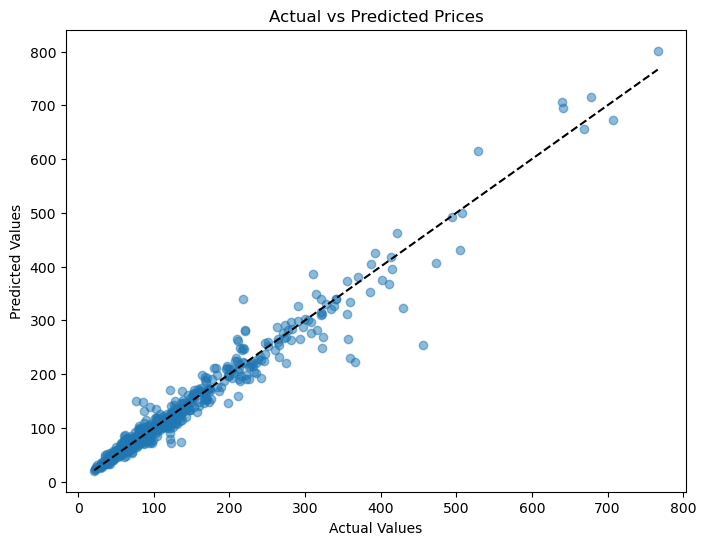

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Prices")
plt.show()